In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.utils.common_funcs import  set_time_grid, cont_integral
from src.spec_dens.spec_dens import SpecDensGapless
import src.utils.common_funcs as cf
from src.kernel_params.kernel_params import KernelParams
from src.kernel_matrix.kernel_matrix import KernelMatrix
from src.discr_error.discr_error import DiscrError
from src.decomp_kernel.decomp_kernel import DecompKernel

Project path successfully added.


In [2]:
Lambda = 10
N_max = 100 #number of time steps
beta = 0 #inverse temperature
sharpness = 10 #sharpness is nu which is MULTIPLIED with (w-Lambda) in the exponent
delta_t = .01

# Define the spectral density
spec_dens = SpecDensGapless(Lambda = Lambda, sharpness = sharpness)

#create the time grid
time_grid = set_time_grid(N_max, delta_t)
print("Largest time: ", time_grid[-1], "time step: ", delta_t)




Largest time:  1.0 time step:  0.01


Compute the discrete kernel, including 
1) "explicit pole"s (added to kernel matrix by default) and 
2) "additional poles" (not considered in the frequency gid optimization but can be included to compare to the physical propagator)

In [3]:
#initialize parameter set
params = KernelParams(spec_dens = spec_dens, n = 5000, m = 1000, N_max = 100, delta_t = delta_t, h = 0.05, beta = beta)

#print maximum frequency and minimum frequency
print("Maximum Frequency: ", np.exp(params.get_param("h") * params.get_param("m")))
print("Minimum Frequency: ", np.exp(-params.get_param("h") * params.get_param("n")))




Maximum Frequency:  5.184705528587072e+21
Minimum Frequency:  2.6691902155412764e-109


In [4]:
#compute poles and residues for given spectral density
additional_poles, additional_residues = spec_dens.poles_residues() #REPLACE THIS WITH THE NEW POLES AND RESIDUES OF THE SPECTRAL DENSITY: 
#explicit poles to always be included
explicit_poles, explicit_residues = spec_dens.explicit_poles_and_residues(params.get_param("h"))

#create kernel matrix which allows for the computation of the discrete propagator
kernel = DiscrError(**params.params, explicit_poles=explicit_poles, explicit_residues=explicit_residues, additional_poles=additional_poles, additional_residues=additional_residues, only_positive_particle=False)
print("Discretization error on bare grid: ", kernel.eps)

#optimize frequency grid
kernel.optimize(update_params=params, rel_error_diff=0.1)#rel_error_dif chosen such that optimization error is at most 10% of the discretization error of the unoptimized grid
print("Optimized grid: m =", params.get_param("m"), "n", params.get_param("n"))
print("New maximum frequency: ", np.exp(params.get_param("h") * params.get_param("m")))
print("New minimum frequency: ", np.exp(-params.get_param("h") * params.get_param("n")))

print("Number of modes: ", 2*(params.get_param("m") + params.get_param("n") + 1))

#compute the discrete propagator along COMPLEX AXIS including only "explicit poles" and "explicit residues"
propag_kernel_cmplx = kernel.discrete_integral(include_additional_poles=False)
print("Discrete propagator along complex axis (time-integrated value): ", cf.time_integrate(propag_kernel_cmplx, params.get_param("delta_t")))


Discretization error on bare grid:  2.588830025624932e-16
Finished grid optimization. Rel. error between new and old discrete integral: 0. Rel. discretization error w.r.t to continuous integral: 2.588830025624932e-16.
Finished grid optimization. Rel. error between new and old discrete integral: 0. Rel. discretization error w.r.t to continuous integral: 2.588830025624932e-16.
Optimized grid: m = 1000 n 5000
New maximum frequency:  5.184705528587072e+21
New minimum frequency:  2.6691902155412764e-109
Number of modes:  12002
Discrete propagator along complex axis (time-integrated value):  (1.4670179005955333-5.329070518200751e-17j)


Compute error for complex contour

In [5]:
#compute the continuous integral along COMPLEX AXIS for only POSITIVE frequencies
cont_integral_particle_cmplx = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens = spec_dens, only_positive=False)#particle
cont_integral_hole_cmplx = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens)#hole

print("Error between discrete complex contour and continous complex contour: ", cf.error_time_integrated(cont_integral_particle_cmplx, propag_kernel_cmplx[:len(time_grid)], params.params["delta_t"]))

Error between discrete complex contour and continous complex contour:  2.5888300256249315e-16


Compute error for Real axis

In [6]:
#compute the continuous integral along REAL AXIS for only POSITIVE frequencies
cont_integral_particle = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens=spec_dens ,phi = 0.) #particle
cont_integral_hole = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens,phi = 0.) #hole

#compute the discrete propagator along REAL AXIS including also "additional_poles" and "additional_residues"
propag_kernel = kernel.discrete_integral(include_additional_poles=True)
print("Error between discrete real-axis and continous real-axis: ", cf.error_time_integrated(cont_integral_particle, propag_kernel[:len(time_grid)], params.params["delta_t"]))

Error between discrete real-axis and continous real-axis:  1.446461642396534e-16


Make consistency check by expicitly including all poles and residues

In [7]:
#make consistency check by expicitly including all poles and residues
#get poles and residues of the spectral density
kernel_particles = 2.j * np.pi * additional_residues * cf.dynamic_distr_particle(time_grid[:, np.newaxis], additional_poles, beta) 
#hole component (negative sign in beta for hole distribution)
kernel_holes = 2.j * np.pi * additional_residues * cf.dynamic_distr_particle(time_grid[:, np.newaxis], additional_poles, -beta) 

#sum over the poles to determine the contribution to the propagator
G_poles_particle = np.sum(kernel_particles, axis = 1)
G_poles_hole = np.sum(kernel_holes, axis = 1)

print("Explicitly including additional poles and residues is consistent: ", np.allclose(np.concatenate((G_poles_particle, G_poles_hole)) + propag_kernel_cmplx, propag_kernel))

Explicitly including additional poles and residues is consistent:  True


Perform ID to make consistency check

In [10]:
#decompose the kernel using ID. Specify include_additional_poles = True to include the additional poles in the kernel that is decomposed
decomp = DecompKernel(kernel, include_additional_poles=True)
#reconstruct the propagator from the decomposed ID-kernel
propag_ID_reconstr = decomp.reconstruct_propagator_ID()


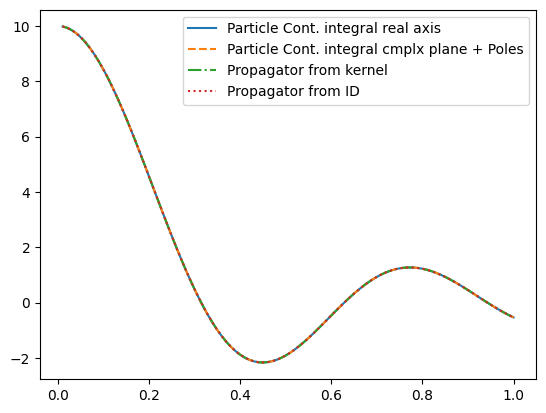

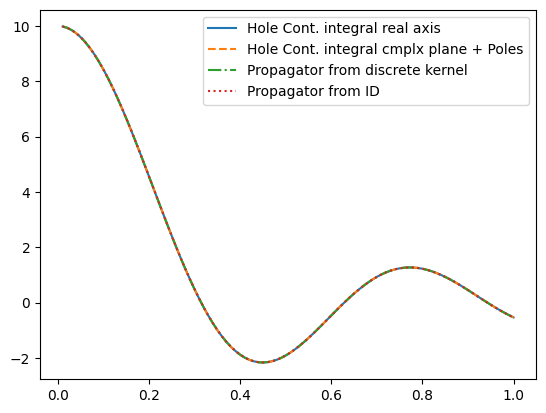

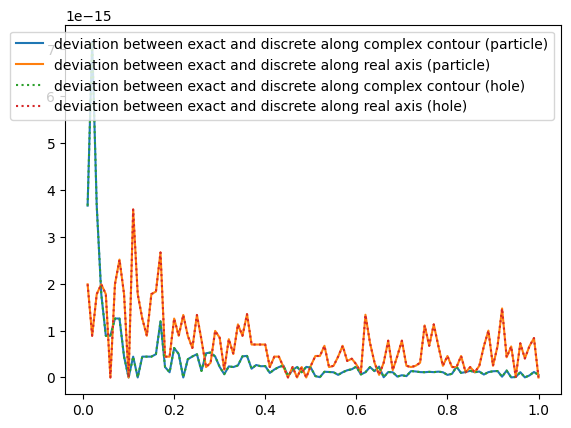

In [14]:

#plot

#particle
plt.plot(time_grid, np.real(cont_integral_particle) , label= "Particle Cont. integral real axis")
plt.plot(time_grid, np.real(G_poles_particle + cont_integral_particle_cmplx), label = "Particle Cont. integral cmplx plane + Poles", linestyle = "--")
plt.plot(time_grid, np.real(propag_kernel)[:len(propag_kernel)//2], label = "Propagator from kernel", linestyle = "dashdot")
plt.plot(time_grid, np.real(propag_ID_reconstr)[:len(propag_kernel)//2], label = "Propagator from ID", linestyle = "dotted")
plt.legend()
plt.show()


#hole
plt.plot(time_grid, np.real(cont_integral_hole) , label= "Hole Cont. integral real axis")
plt.plot(time_grid, np.real(G_poles_hole + cont_integral_hole_cmplx), label = "Hole Cont. integral cmplx plane + Poles", linestyle = "--")
plt.plot(time_grid, np.real(propag_kernel)[len(propag_kernel)//2:], label = "Propagator from discrete kernel", linestyle = "dashdot")
plt.plot(time_grid, np.real(propag_ID_reconstr)[len(propag_kernel)//2:], label = "Propagator from ID", linestyle = "dotted")
plt.legend()
plt.show()


#plot error as function of time
plt.plot(time_grid, abs(cont_integral_particle_cmplx - propag_kernel_cmplx[:len(time_grid)]), linestyle = "-", label = "deviation between exact and discrete along complex contour (particle)")
plt.plot(time_grid, abs(cont_integral_particle - propag_kernel[:len(time_grid)]), linestyle = "-", label = "deviation between exact and discrete along real axis (particle)")
plt.plot(time_grid, abs(cont_integral_hole_cmplx - propag_kernel_cmplx[len(propag_kernel)//2:]), linestyle = "dotted", label = "deviation between exact and discrete along complex contour (hole)")
plt.plot(time_grid, abs(cont_integral_hole - propag_kernel[len(propag_kernel)//2:]),linestyle = "dotted", label = "deviation between exact and discrete along real axis (hole)")
plt.legend()
plt.show()